<a href="https://colab.research.google.com/github/Aphatsara-Khangkhet/DADS5001-BKK-Flow/blob/main/Graph08_Real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# กราฟ 08 — คำนวณการจับคู่จริง

เปิดใน Colab และ Run all โค้ดและฟอนต์ฝังไว้ใน Notebook แล้ว ไม่ต้องหา src เพิ่ม ใช้ covid_period ตามไฟล์และคงป้าย Lockdown เดิม ทุกครั้งจะ audit และคำนวณใหม่ ไม่มีตัวเลขสาธิตหรือผลสำรองเมื่อไม่มีคู่ข้อมูล

กราฟ 08 ใน Notebook นี้หมายถึงกราฟเงื่อนไขการจับคู่จาก README นำเสนอล่าสุด ไม่ใช่กราฟวันสำรวจชื่อ 08.png ในชุด BKK6 เก่า

In [1]:
import os, sys, subprocess
os.environ['OPENBLAS_NUM_THREADS'] = '1'
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'pandas', 'numpy', 'matplotlib', 'openpyxl'])
from pathlib import Path
import datetime, base64, io, zipfile, json
from IPython.display import display, Markdown, Image, FileLink


In [2]:
RUNTIME = Path.cwd() / ('bkk6_' + datetime.datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
RUNTIME.mkdir()
PAYLOAD = '...'
with zipfile.ZipFile(io.BytesIO(base64.b64decode(PAYLOAD))) as z:
    for member in z.infolist():
        assert (RUNTIME / member.filename).resolve().is_relative_to(RUNTIME.resolve())
    z.extractall(RUNTIME)
sys.path.insert(0, str(RUNTIME / 'src'))
print('โมดูลพร้อม:', RUNTIME)


โมดูลพร้อม: /content/bkk6_20260920_062742_548167


In [3]:
# เปลี่ยน INPUT ได้เมื่อใช้ไฟล์ใหม่ ชีตต้องเป็น traffic_data
INPUT = Path.home() / 'Downloads' / 'bangkok_traffic_2560_Present (NotFinal) (6).xlsx'
if not INPUT.is_file():
    if not IN_COLAB:
        raise FileNotFoundError('แก้ INPUT เป็นพาธไฟล์ Excel ของคุณก่อนรันต่อ')
    uploaded = files.upload()
    choices = [name for name in uploaded if name.lower().endswith('.xlsx')]
    if len(choices) != 1:
        raise ValueError('เลือกไฟล์ Excel หนึ่งไฟล์เท่านั้น')
    INPUT = Path(choices[0]).resolve()
print('ข้อมูลที่เลือก:', INPUT.name)


Saving bangkok_traffic_2560_2568.xlsx to bangkok_traffic_2560_2568.xlsx
ข้อมูลที่เลือก: bangkok_traffic_2560_2568.xlsx


## สูตรและโค้ดกราฟ 08

ทางแยก + ถนน + เวลาเป็นฐานทุกแบบ เพิ่มไตรมาสรายงานหรือเดือนสำรวจบนฐานเดิม หามัธยฐานคันต่อชั่วโมงรายหน่วยและช่วง แล้วหารฐานก่อนของหน่วยเดียวกันก่อนสรุปมัธยฐานข้ามหน่วย

In [4]:
"""กราฟ 08 ของ README ล่าสุด: ผลจริงตามเงื่อนไขการจับคู่ ไม่มีค่าสาธิต."""
from pathlib import Path
import argparse, hashlib, json
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
import audit_core

ROOT=RUNTIME
P=['ก่อนโควิด','โควิด','หลังโควิด']
K=['intersection_key','road_key','time_key']
V=audit_core.VEHICLES

def font():
 f=ROOT/'assets/NotoSansThai.ttf'
 if f.exists():
  font_manager.fontManager.addfont(str(f))
  plt.rcParams['font.family']=[font_manager.FontProperties(fname=str(f)).get_name(),'DejaVu Sans']
 plt.rcParams.update({'font.size':11,'axes.unicode_minus':False})

def prepare(source, work):
 """Always audit the supplied workbook. Keep source and original flags unchanged."""
 work=Path(work).resolve();work.mkdir(parents=True,exist_ok=False)
 for name in ['data/interim','data/processed']:(work/name).mkdir(parents=True)
 audit_core.ROOT=work
 info=audit_core.run_audit(source,work/'audit')
 if info['unknown_period_rows']:raise ValueError('มี covid_period ที่ไม่รู้จัก: ตรวจ audit ก่อน')
 d=pd.read_csv(work/'data/processed/traffic_candidates.csv',low_memory=False)
 d=d[d.survey_date_parsed.notna() & d.survey_year.ge(2017)].copy()
 d['total']=d[[v+'_clean' for v in V]].sum(axis=1)
 d['vph']=d['total']/d['period_hours']
 return d,info

def paired(d,keys):
 """Median per unit-period -> ratio within unit -> median across units."""
 wide=d.groupby(keys+['covid_period'],dropna=False)['vph'].median().unstack()
 wide=wide.reindex(columns=P).dropna()
 wide=wide.loc[wide[P[0]].gt(0)]
 return wide,wide.div(wide[P[0]],axis=0)*100

def compute(d):
 definitions=[('สถานที่ + ถนน + เวลา',K),
              ('เพิ่มไตรมาสรายงานเดียวกัน',K+['report_quarter']),
              ('เพิ่มเดือนสำรวจเดียวกัน',K+['survey_month'])]
 summary=[];detail={}
 for label,keys in definitions:
  wide,index=paired(d,keys)
  matched=d.merge(wide.reset_index()[keys],on=keys,how='inner',validate='many_to_one')
  n=len(wide)
  summary.append({'design':label,'units':n,'rows':len(matched),
    'Before':100.0 if n else np.nan,
    'During':index[P[1]].median() if n else np.nan,
    'After':index[P[2]].median() if n else np.nan,
    'before_rows':int(matched.covid_period.eq(P[0]).sum()),
    'during_rows':int(matched.covid_period.eq(P[1]).sum()),
    'after_rows':int(matched.covid_period.eq(P[2]).sum())})
  detail[label]=index.reset_index()
 if not summary[0]['units']:raise ValueError('ไม่มีหน่วยฐานบวกที่จับคู่ครบสามช่วง จึงไม่สร้างกราฟผล')
 return pd.DataFrame(summary),detail

def draw(summary,path):
 font();fig,ax=plt.subplots(figsize=(13,6.5));x=np.arange(len(summary));w=.24
 for j,(col,label,color) in enumerate(zip(['Before','During','After'],['ก่อนโควิด','ระหว่างโควิด','หลังโควิด'],['#557C9B','#D58A36','#178778'])):
  bars=ax.bar(x+(j-1)*w,summary[col],w,color=color,label=label)
  ax.bar_label(bars,fmt='%.1f',padding=3)
 ax.set_xticks(x,[f'{r.design}\n{r.units} หน่วย / {r.rows:,} แถว' for r in summary.itertuples()])
 ax.set_ylabel('ค่ามัธยฐานของดัชนีรายหน่วย (ก่อนโควิด = 100)')
 ax.set_title('08. ผลเปรียบเทียบสามช่วง เมื่อเพิ่มเงื่อนไขการจับคู่ข้อมูล',pad=18)
 ax.axhline(100,color='#74848b',ls='--',lw=1);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.13),ncol=3,frameon=False)
 ax.spines[['top','right']].set_visible(False);ax.margins(y=.15)
 for i,r in enumerate(summary.itertuples()):
  if not r.units:ax.text(i,15,'ไม่มีคู่ข้อมูล',ha='center')
 fig.text(.5,.02,'ใช้ covid_period ตามไฟล์ • หน่วยที่เพิ่มเดือน/ไตรมาสมีนิยามและสมาชิกต่างจากชุดหลัก • ไม่ใช่ผลเชิงสาเหตุ',ha='center',fontsize=10)
 fig.tight_layout(rect=(0,.06,1,1));fig.savefig(path,dpi=170,facecolor='white');plt.close(fig)

def export(d,folder):
 folder=Path(folder);(folder/'fig').mkdir(parents=True,exist_ok=True);(folder/'tables').mkdir(exist_ok=True)
 summary,detail=compute(d)
 summary.to_csv(folder/'tables/08_matching.csv',index=False,encoding='utf-8-sig')
 for i,frame in enumerate(detail.values(),1):frame.to_csv(folder/'tables'/f'08_units_{i}.csv',index=False,encoding='utf-8-sig')
 draw(summary,folder/'fig/08_matching.png')
 return summary



,design,units,rows,Before,During,After,before_rows,during_rows,after_rows
0,สถานที่ + ถนน + เวลา,721,3045,100.0,91.464821,90.238460,1045,893,1107
1,เพิ่มไตรมาสรายงานเดียวกัน,76,256,100.0,87.677290,87.295163,87,87,82
2,เพิ่มเดือนสำรวจเดียวกัน,18,56,100.0,87.291259,94.127887,20,18,18


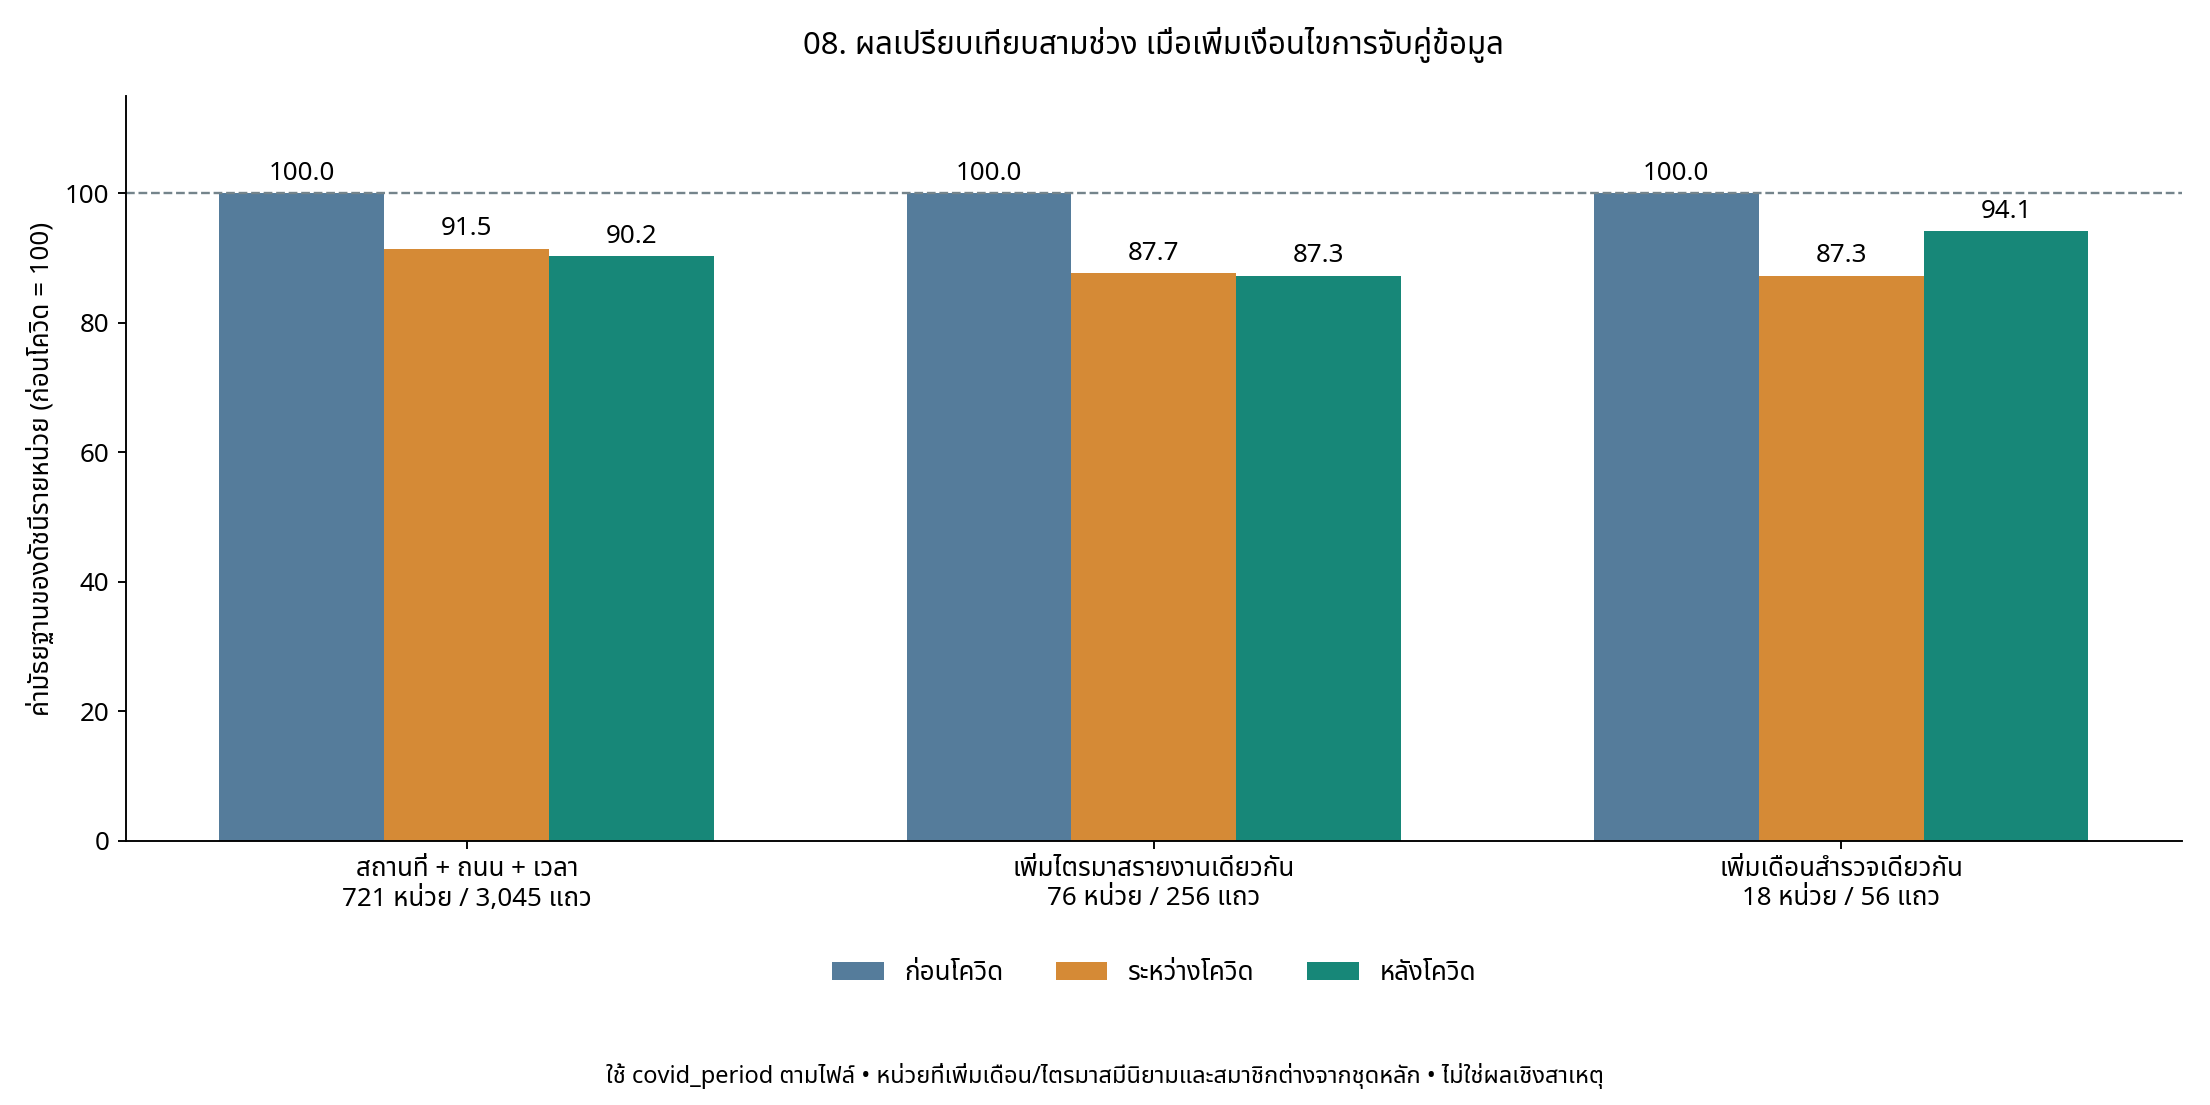

SHA256: c8b180d35d66851f05d1cbd4419649303fac4dd3249913e3032118c95ffecc77


In [5]:
REPORT = RUNTIME / 'graph08_result'
d, audit_info = prepare(INPUT, REPORT)
summary = export(d, REPORT)
display(summary)
display(Image(filename=str(REPORT / 'fig/08_matching.png')))
print('SHA256:', audit_info['source_sha256'])


## ดาวน์โหลดผล

เปิด README หรือ INSIGHTS.md คู่กับโฟลเดอร์ fig และ tables ห้ามสลับผลคนละรุ่น กราฟเป็นผลเชิงพรรณนาของชุดสำรวจ ไม่พิสูจน์ผลเชิงสาเหตุของโควิด

In [6]:
import shutil
archive = shutil.make_archive(str(RUNTIME / 'result'), 'zip', REPORT)
print(archive)
if IN_COLAB:
    files.download(archive)
else:
    display(FileLink(archive))


/content/bkk6_20260920_062742_548167/result.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>